# Image Optimizer Notebook

Supports:
- JPEG, PNG, WebP, BMP, TIFF input
- Resize while preserving aspect ratio
- Target maximum dimensions
- Target maximum file size
- JPEG/WebP binary-search quality optimization
- PNG palette optimization


In [43]:
!pip install pillow

In [44]:
from PIL import Image, ImageEnhance
from pathlib import Path
import io, os

# ==========================
# USER CONFIGURATION
# ==========================

IMAGE_REL_PATH = Path(r"images\Product 1\white_bg (3).png")
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "images").exists() else Path.cwd().parent
INPUT_IMAGE = str((PROJECT_ROOT / IMAGE_REL_PATH).resolve()) # Input image path
OUTPUT_FORMAT = "same"     # same, jpeg, png, webp

MAX_WIDTH = 333
MAX_HEIGHT = 500

TARGET_SIZE_KB = 30

RESIZE = True
COMPRESS = True
KEEP_ASPECT = True  # Set False to force exact size
USE_WHITE_BACKGROUND = True
WHITE_BACKGROUND_COLOR = (255, 255, 255)

JPEG_MIN_QUALITY = 20
JPEG_MAX_QUALITY = 95

WEBP_MIN_QUALITY = 20
WEBP_MAX_QUALITY = 95

# Set values < 1.0 to reduce sharpness/contrast, > 1.0 to increase
SHARPNESS_FACTOR = 1.5
CONTRAST_FACTOR = 0.80



In [45]:
def file_size_kb(path):
    return os.path.getsize(path)/1024

def image_info(path):
    img = Image.open(path)
    return {
        "format": img.format,
        "mode": img.mode,
        "width": img.width,
        "height": img.height,
        "size_kb": file_size_kb(path)
    }

def print_info(title, info):
    print("="*40)
    print(title)
    for k,v in info.items():
        print(f"{k:10}: {v}")


In [46]:
def generate_image_sizes(image_path, scales=(0.75, 0.50, 0.25)):
    """
    Generate smaller image dimensions while maintaining the original aspect ratio.
    """

    info = image_info(image_path)

    original_width = info["width"]
    original_height = info["height"]

    versions = []

    for scale in scales:
        versions.append({
            "scale": scale,
            "width": int(original_width * scale),
            "height": int(original_height * scale)
        })

    return versions

In [47]:
SCALES = [1.0, 0.75, 0.50, 0.25]   # Configurable


def generate_image_sizes(image_path, scales=SCALES):
    info = image_info(image_path)

    width = info["width"]
    height = info["height"]

    versions = []

    for scale in scales:
        if scale >= 1:
            continue  # Skip original size

        versions.append({
            "scale": scale,
            "width": int(width * scale),
            "height": int(height * scale)
        })

    return versions


def resize_image(img, width, height):
    if not RESIZE:
        return img.copy()

    return img.resize((width, height), Image.LANCZOS)


In [48]:
def save_jpeg(img, output, target_kb):
    if img.mode in ("RGBA","LA","P"):
        img = img.convert("RGB")

    low = JPEG_MIN_QUALITY
    high = JPEG_MAX_QUALITY
    best = None

    while low <= high:
        q = (low + high)//2
        buf = io.BytesIO()

        img.save(buf,
                 format="JPEG",
                 quality=q,
                 optimize=False)

        size = len(buf.getvalue())/1024

        if size <= target_kb:
            best = buf.getvalue()
            low = q + 1
        else:
            high = q - 1

    if best is None:
        buf = io.BytesIO()
        img.save(buf,
                 format="JPEG",
                 quality=JPEG_MIN_QUALITY,
                 optimize=False)
        best = buf.getvalue()

    with open(output,"wb") as f:
        f.write(best)


In [49]:
def save_webp(img, output, target_kb):
    low = WEBP_MIN_QUALITY
    high = WEBP_MAX_QUALITY
    best = None

    while low <= high:
        q = (low+high)//2

        buf = io.BytesIO()
        img.save(buf,
                 format="WEBP",
                 quality=q,
                 method=6)

        size = len(buf.getvalue())/1024

        if size <= target_kb:
            best = buf.getvalue()
            low = q + 1
        else:
            high = q - 1

    if best is None:
        buf = io.BytesIO()
        img.save(buf,
                 format="WEBP",
                 quality=WEBP_MIN_QUALITY,
                 method=6)
        best = buf.getvalue()

    with open(output,"wb") as f:
        f.write(best)


In [50]:
def save_png(img, output, target_kb):

    # palette_sizes = [256,128,64,32,16,8,4]
    palette_sizes = [256,128,64,32]

    best = None

    for colors in palette_sizes:

        test = img.convert(
            "P",
            palette=Image.ADAPTIVE,
            colors=colors
        )

        buf = io.BytesIO()

        test.save(buf,
                  format="PNG",
                  optimize=True,
                  compress_level=9)

        size = len(buf.getvalue())/1024

        best = buf.getvalue()

        if size <= target_kb:
            print(f"Achieved target size with {colors} colors.")
            break

    with open(output,"wb") as f:
        f.write(best)


In [51]:
def optimize_image(input_path):

    def enhance_image(img):
        enhancer = ImageEnhance.Sharpness(img)
        return enhancer.enhance(SHARPNESS_FACTOR)

    def white_background(img):
        if img.mode != "RGBA":
            img = img.convert("RGBA")

        background = Image.new(
            "RGBA",
            img.size,
            WHITE_BACKGROUND_COLOR + (255,)
        )

        background.paste(img, mask=img.split()[3])

        return background.convert("RGB")

    # -------------------------
    # Original Image Info
    # -------------------------

    info = image_info(input_path)
    print_info("Original", info)

    # Generate all resize versions
    sizes = generate_image_sizes(input_path)

    # Output format
    fmt = OUTPUT_FORMAT.lower()

    if fmt == "same":
        fmt = info["format"].lower()

    input_file = Path(input_path)

    output_dir = input_file.parent / "optimised"
    output_dir.mkdir(parents=True, exist_ok=True)

    # Open original image only once
    original_img = Image.open(input_path)

    generated_files = []

    # -------------------------
    # Generate Images
    # -------------------------

    for version in sizes:

        img = resize_image(
            original_img.copy(),
            version["width"],
            version["height"]
        )

        if USE_WHITE_BACKGROUND:
            img = white_background(img)

        img = enhance_image(img)

        output = (
            output_dir /
            f"{input_file.stem}_{version['width']}x{version['height']}"
        )

        if fmt in ("jpg", "jpeg"):

            output = output.with_suffix(".jpg")

            save_jpeg(
                img,
                str(output),
                TARGET_SIZE_KB
            )

        elif fmt == "png":

            output = output.with_suffix(".png")

            save_png(
                img,
                str(output),
                TARGET_SIZE_KB
            )

        elif fmt == "webp":

            output = output.with_suffix(".webp")

            save_webp(
                img,
                str(output),
                TARGET_SIZE_KB
            )

        else:
            raise ValueError(f"Unsupported output format: {fmt}")

        generated_files.append(str(output))

        print(version)

        print_info(
            f"Optimized ({version['width']}x{version['height']})",
            image_info(str(output))
        )

        reduction = (
            100
            * (
                1
                - file_size_kb(str(output))
                / info["size_kb"]
            )
        )

        print(f"Reduction: {reduction:.2f}%")

    return generated_files

Original
format    : PNG
mode      : RGB
width     : 512
height    : 768
size_kb   : 240.4013671875
{'scale': 0.75, 'width': 384, 'height': 576}
Optimized (384x576)
format    : PNG
mode      : P
width     : 384
height    : 576
size_kb   : 38.6748046875
Reduction: 83.91%
Achieved target size with 64 colors.
{'scale': 0.5, 'width': 256, 'height': 384}
Optimized (256x384)
format    : PNG
mode      : P
width     : 256
height    : 384
size_kb   : 25.95703125
Reduction: 89.20%
Achieved target size with 256 colors.
{'scale': 0.25, 'width': 128, 'height': 192}
Optimized (128x192)
format    : PNG
mode      : P
width     : 128
height    : 192
size_kb   : 13.046875
Reduction: 94.57%

Generated Files:
C:\Users\JaiminUnagar\OneDrive - inkeysolutions.com\Extension\images\Product 1\optimised\white_bg (3)_384x576.png
C:\Users\JaiminUnagar\OneDrive - inkeysolutions.com\Extension\images\Product 1\optimised\white_bg (3)_256x384.png
C:\Users\JaiminUnagar\OneDrive - inkeysolutions.com\Extension\images\Prod

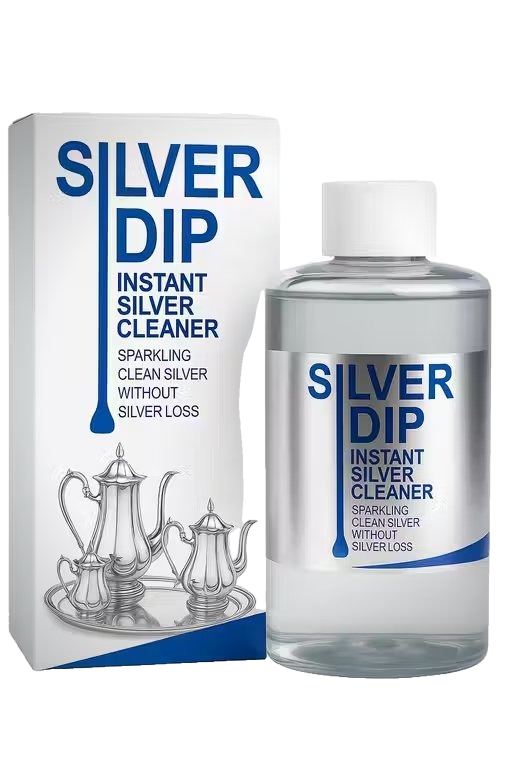

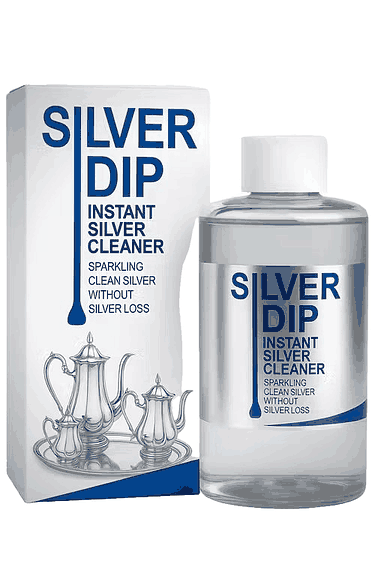

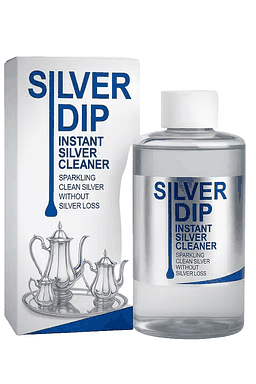

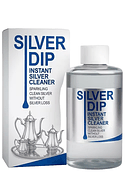

In [52]:
outputs = optimize_image(INPUT_IMAGE)
# print(len(outputs), "files generated.")

print("\nGenerated Files:")

for file in outputs:
    print(file)

display(Image.open(INPUT_IMAGE))

for file in outputs:
    display(Image.open(file))

In [53]:
from PIL import Image

# Open the image
img = Image.open(INPUT_IMAGE).convert("RGB")

# Get color of the top-left corner pixel (x=0, y=0)
r, g, b = img.getpixel((0, 0))

# Convert RGB to HEX format
hex_color = f"#{r:02x}{g:02x}{b:02x}"

print(f"RGB Color: ({r}, {g}, {b})")
print(f"HEX Color: {hex_color.upper()}")

# Quick check if it's pure white
if hex_color.upper() == "#FFFFFF":
    print("The background is pure white.")
else:
    print("The background is NOT pure white.")

RGB Color: (255, 255, 255)
HEX Color: #FFFFFF
The background is pure white.
